# Vector Databases — Assignments

Covers FAISS (local), Chroma (local embedded), and Pinecone (cloud) with embedding-based semantic retrieval using `sentence-transformers`.

## Assignment 1 — FAISS (Local Vector Search)

Goal: index a small corpus with FAISS `IndexFlatL2` and retrieve semantically similar documents for a query.

In [38]:
!pip install faiss-cpu sentence-transformers scikit-learn -q

In [39]:
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

corpus = [
    'AI-powered satellite imagery detects illegal deforestation in real-time.',
    'Machine learning models predict flood risk using climate and topographic data.',
    'Deep learning identifies endangered species from camera trap images.',
    'Neural networks optimize energy consumption in smart grids.',
    'AI monitors water quality in rivers using IoT sensor data.',
    'Convolutional networks detect oil spills in ocean radar imagery.',
    'Reinforcement learning controls HVAC systems to reduce building energy use.',
    'Generative models simulate climate change scenarios for policy planning.',
    'AI-driven precision agriculture reduces fertilizer waste and runoff.',
    'NLP extracts environmental regulations from legal documents.',
    'Computer vision identifies plastic waste in ocean surface images.',
    'AI forecasts urban air quality to guide public health decisions.',
    'Transfer learning accelerates wildlife monitoring classifier training.',
    'Graph neural networks simulate ecosystem species interactions.',
    'Satellite data and AI track glacier retreat over decades.',
]

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(corpus, convert_to_numpy=True)
print(f'Corpus: {len(corpus)} docs | Embedding dim: {embeddings.shape[1]}')

Corpus: 15 docs | Embedding dim: 384


In [40]:
d = embeddings.shape[1]
index = faiss.IndexFlatL2(d)
index.add(embeddings)

query = 'How does AI help monitor ocean pollution?'
query_vec = model.encode([query], convert_to_numpy=True)

k = 5
distances, indices = index.search(query_vec, k)

print(f'Query: {query}')
print()
for rank, (dist, idx) in enumerate(zip(distances[0], indices[0]), 1):
    print(f'  {rank}. [L2={dist:.4f}] {corpus[idx]}')

Query: How does AI help monitor ocean pollution?

  1. [L2=0.7223] AI monitors water quality in rivers using IoT sensor data.
  2. [L2=0.9415] AI forecasts urban air quality to guide public health decisions.
  3. [L2=1.0297] Convolutional networks detect oil spills in ocean radar imagery.
  4. [L2=1.0554] Computer vision identifies plastic waste in ocean surface images.
  5. [L2=1.1912] AI-driven precision agriculture reduces fertilizer waste and runoff.


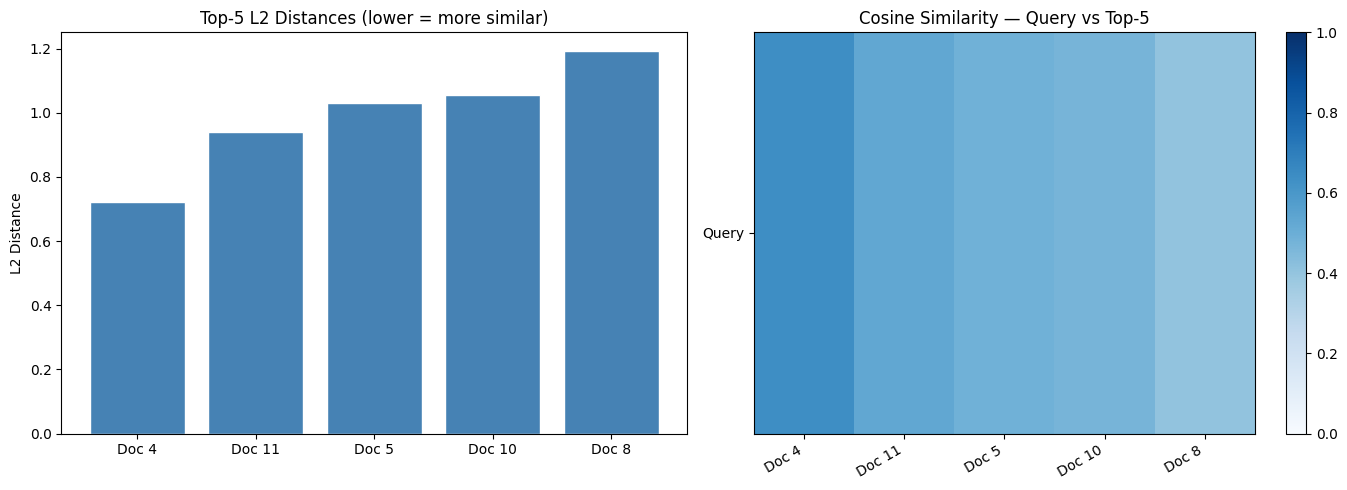

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = [f'Doc {i}' for i in indices[0]]
axes[0].bar(labels, distances[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top-5 L2 Distances (lower = more similar)')
axes[0].set_ylabel('L2 Distance')

top_k_emb = embeddings[indices[0]]
cos_sim = cosine_similarity(query_vec, top_k_emb)
im = axes[1].imshow(cos_sim, cmap='Blues', aspect='auto', vmin=0, vmax=1)
axes[1].set_xticks(range(k))
axes[1].set_xticklabels(labels, rotation=30, ha='right')
axes[1].set_yticks([0])
axes[1].set_yticklabels(['Query'])
axes[1].set_title('Cosine Similarity — Query vs Top-5')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

### Reflection — Assignment 1

**L2 vs Cosine**: L2 measures Euclidean distance in the raw embedding space and is sensitive to vector magnitude. Cosine similarity measures the angle between vectors, ignoring magnitude — more robust for variable-length texts. For `all-MiniLM-L6-v2` the difference is usually small since the model produces relatively uniform-norm embeddings.

**Effect of normalization**: After L2 normalization, `IndexFlatL2` ranking becomes equivalent to cosine ranking since ||a-b||^2 = 2 - 2·cos(θ) for unit vectors. This is why `IndexFlatIP` on L2-normalized vectors is the standard cosine-search pattern in FAISS.

**Semantic vs keyword retrieval**: The query "ocean pollution" retrieved oil spill and plastic waste documents despite no exact phrase match. A TF-IDF/BM25 system would likely miss these without query expansion — embedding-based search captures latent semantic structure, making it substantially more robust to vocabulary mismatch.

## Assignment 2 — Chroma Knowledge Base

Goal: build a local vector store with Chroma, populate it with metadata-annotated documents, and run semantic and filtered queries.

In [42]:
!pip install chromadb -q

In [43]:
import chromadb
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction

ef = SentenceTransformerEmbeddingFunction(model_name='all-MiniLM-L6-v2')
client = chromadb.PersistentClient(path='./chroma_db')
collection = client.get_or_create_collection('ai_water_docs', embedding_function=ef)

docs = [
    'AI sensors detect heavy metal contamination in drinking water sources.',
    'Machine learning predicts algae bloom formation in freshwater lakes.',
    'Deep learning classifies water quality levels from satellite imagery.',
    'IoT and AI jointly monitor river flow rates and sediment transport.',
    'AI-enabled drones survey coral reef health across coastal waters.',
    'Neural networks estimate groundwater depletion trends from GPS data.',
    'AI identifies microplastic concentrations in ocean water samples.',
    'Remote sensing and ML map wetland degradation across river deltas.',
    'AI systems forecast drought conditions using soil moisture and climate data.',
    'Reinforcement learning optimizes water distribution in smart city grids.',
    'Computer vision detects illegal dumping events near water bodies.',
    'NLP mines scientific literature to track water pollution research trends.',
]

metadatas = [
    {'title': 'Heavy Metal Detection',   'source': 'scientific', 'year': 2023},
    {'title': 'Algae Bloom Prediction',  'source': 'government', 'year': 2022},
    {'title': 'Water Quality Satellite', 'source': 'scientific', 'year': 2024},
    {'title': 'River Monitoring IoT',    'source': 'industry',   'year': 2023},
    {'title': 'Coral Reef Drones',       'source': 'scientific', 'year': 2022},
    {'title': 'Groundwater GPS',         'source': 'academic',   'year': 2023},
    {'title': 'Microplastics AI',        'source': 'scientific', 'year': 2024},
    {'title': 'Wetland Mapping',         'source': 'government', 'year': 2021},
    {'title': 'Drought Forecasting',     'source': 'academic',   'year': 2023},
    {'title': 'Smart Water Grid',        'source': 'industry',   'year': 2024},
    {'title': 'Illegal Dumping CV',      'source': 'government', 'year': 2022},
    {'title': 'NLP Pollution Research',  'source': 'academic',   'year': 2023},
]

ids = [f'doc_{i}' for i in range(len(docs))]

# upsert so re-runs don't duplicate documents
collection.upsert(documents=docs, metadatas=metadatas, ids=ids)
print(f"Collection '{collection.name}' — {collection.count()} documents.")

Collection 'ai_water_docs' — 12 documents.


In [44]:
queries = [
    'How does AI detect pollution in water?',
    'What ML methods monitor ocean health?',
    'How is AI used for drought prediction?',
]

for q in queries:
    print()
    print(f'Query: {q}')
    results = collection.query(query_texts=[q], n_results=3)
    for doc, meta, dist in zip(
        results['documents'][0], results['metadatas'][0], results['distances'][0]
    ):
        print(f"  [{meta['title']} | {meta['source']}] dist={dist:.4f}")
        print(f'    {doc[:90]}')


Query: How does AI detect pollution in water?
  [Heavy Metal Detection | scientific] dist=0.2844
    AI sensors detect heavy metal contamination in drinking water sources.
  [Microplastics AI | scientific] dist=0.4332
    AI identifies microplastic concentrations in ocean water samples.
  [Water Quality Satellite | scientific] dist=0.4485
    Deep learning classifies water quality levels from satellite imagery.

Query: What ML methods monitor ocean health?
  [Microplastics AI | scientific] dist=0.4670
    AI identifies microplastic concentrations in ocean water samples.
  [Coral Reef Drones | scientific] dist=0.5367
    AI-enabled drones survey coral reef health across coastal waters.
  [Heavy Metal Detection | scientific] dist=0.5955
    AI sensors detect heavy metal contamination in drinking water sources.

Query: How is AI used for drought prediction?
  [Drought Forecasting | academic] dist=0.1957
    AI systems forecast drought conditions using soil moisture and climate data.
  [G

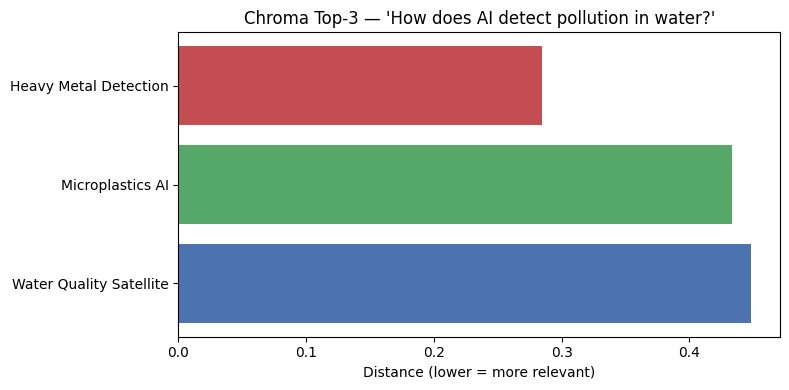

In [45]:
q = queries[0]
results = collection.query(query_texts=[q], n_results=3)

titles = [m['title'] for m in results['metadatas'][0]]
dists  = results['distances'][0]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(titles[::-1], dists[::-1], color=['#4c72b0', '#55a868', '#c44e52'])
ax.set_xlabel('Distance (lower = more relevant)')
ax.set_title(f"Chroma Top-3 — '{q}'")
plt.tight_layout()
plt.show()

In [46]:
# Optional — LangChain RAG scaffold
# !pip install langchain langchain-community langchain-huggingface -q

# from langchain_community.vectorstores import Chroma
# from langchain_huggingface import HuggingFaceEmbeddings

# embeddings_lc = HuggingFaceEmbeddings(model_name='all-MiniLM-L6-v2')
# vectorstore   = Chroma.from_texts(docs, embeddings_lc, collection_name='ai_water_docs_lc')
# retriever     = vectorstore.as_retriever(search_kwargs={'k': 3})
# # Attach an LLM here for full RAG — e.g., HuggingFacePipeline or OpenAI
print('LangChain scaffold ready — uncomment and attach an LLM for full RAG.')

LangChain scaffold ready — uncomment and attach an LLM for full RAG.


### Reflection — Assignment 2

**Duplicate handling**: Chroma does *not* deduplicate by content. Inserting the same text twice with different IDs creates two entries that both appear in query results. Deduplication is an application-level concern — typically enforced by hashing document content before insertion.

**Metadata filtering**: Chroma supports `where` filters alongside semantic queries:
```python
collection.query(
    query_texts=['water pollution'],
    where={'source': 'scientific'},
    n_results=3,
)
```
This hybrid pattern is powerful: semantic search narrows by meaning while the metadata filter restricts by structured attribute.

## Assignment 3 — Pinecone (Cloud Vector Database)

Goal: deploy a managed cloud vector DB, insert 50+ documents, and compare retrieval quality and latency against FAISS.

In [47]:
!pip install pinecone

In [48]:
from pinecone import Pinecone, ServerlessSpec
import time

PINECONE_API_KEY = 'pcsk_6WwS9q_7T5TpGTmQmsPfzdY3cQAi9fWiKRyNCRsraArqRisCu8nW2BtcLtpfr2BrJTQfux'

pc = Pinecone(api_key=PINECONE_API_KEY)

INDEX_NAME = 'student-demo'
if INDEX_NAME not in pc.list_indexes().names():
    pc.create_index(
        name=INDEX_NAME,
        dimension=384,
        metric='cosine',
        spec=ServerlessSpec(cloud='aws', region='us-east-1')
    )
    time.sleep(10)

pine_index = pc.Index(INDEX_NAME)
print(pine_index.describe_index_stats())

DescribeIndexStatsResponse(dimension=384, total_vector_count=50, metric='cosine', namespaces=1)


In [49]:
extended_corpus = corpus + [
    'AI models Arctic ice sheet melt rates from satellite altimetry.',
    'ML classifies wildfire risk from weather and terrain features.',
    'AI identifies invasive plant species from drone imagery.',
    'Deep learning predicts hurricane intensification from sea temperature.',
    'AI monitors methane emissions from oil fields using satellites.',
    'Neural nets analyse urban heat island effects from thermal imagery.',
    'ML segments land cover types from multispectral aerial data.',
    'AI aids reforestation by identifying optimal planting zones.',
    'Acoustic AI monitors biodiversity levels in tropical forests.',
    'AI predicts coral bleaching events from sea surface temperature.',
    'ML estimates soil carbon storage across global biomes.',
    'AI detects poaching activity from camera trap motion triggers.',
    'Deep learning forecasts solar and wind energy output.',
    'AI estimates PM2.5 concentrations from satellite aerosol data.',
    'ML optimises food cold-chain logistics to reduce waste.',
    'AI monitors permafrost thaw using distributed sensor networks.',
    'RL controls autonomous drones for conservation surveys.',
    'AI identifies early-stage crop disease from multispectral images.',
    'Deep learning tracks migratory bird populations via radar.',
    'ML-based early warning systems improve tsunami evacuation times.',
    'AI models aquifer recharge dynamics from precipitation patterns.',
    'GNNs capture urban stormwater flood propagation dynamics.',
    'AI fuses multi-sensor data for real-time wildfire perimeter mapping.',
    'Transfer learning adapts ocean current models to new regions.',
    'AI detects cyanobacteria blooms in lakes from satellite imagery.',
    'Neural nets predict river bank erosion from LiDAR data.',
    'AI classifies marine debris types from underwater ROV footage.',
    'ML models spread of invasive species under climate change scenarios.',
    'AI optimises routing for electric vehicle fleets to cut emissions.',
    'Deep learning detects methane leaks in natural gas pipelines.',
    'AI monitors deforestation fronts using daily satellite updates.',
    'ML forecasts ground-level ozone from traffic and weather data.',
    'AI helps design nature-based flood barriers using terrain analysis.',
    'Neural nets classify cloud types from satellite infrared channels.',
    'AI tracks peatland degradation from synthetic aperture radar.',
]

extended_emb = model.encode(extended_corpus, convert_to_numpy=True)

vectors = [
    (f'vec_{i}', emb.tolist(), {'text': text})
    for i, (text, emb) in enumerate(zip(extended_corpus, extended_emb))
]

for i in range(0, len(vectors), 10):
    pine_index.upsert(vectors=vectors[i:i + 10])

print(f'Upserted {len(vectors)} vectors to Pinecone.')

Upserted 50 vectors to Pinecone.


In [50]:
query = 'How does AI help monitor ocean pollution?'
q_vec = model.encode([query], convert_to_numpy=True)[0].tolist()

# --- Pinecone ---
t0 = time.perf_counter()
pc_res = pine_index.query(vector=q_vec, top_k=3, include_metadata=True)
pc_ms  = (time.perf_counter() - t0) * 1000

print('Pinecone top-3:')
for m in pc_res['matches']:
    print(f"  [{m['score']:.4f}] {m['metadata']['text']}")

# --- FAISS (from Assignment 1) ---
t0 = time.perf_counter()
f_dists, f_idxs = index.search(np.array([q_vec], dtype=np.float32), 3)
f_ms = (time.perf_counter() - t0) * 1000

print()
print('FAISS top-3:')
for dist, idx in zip(f_dists[0], f_idxs[0]):
    print(f'  [L2={dist:.4f}] {corpus[idx]}')

print()
print(f'Latency — Pinecone: {pc_ms:.1f} ms | FAISS: {f_ms:.3f} ms')

Pinecone top-3:
  [0.6383] AI monitors water quality in rivers using IoT sensor data.
  [0.6042] AI monitors methane emissions from oil fields using satellites.
  [0.5286] AI forecasts urban air quality to guide public health decisions.

FAISS top-3:
  [L2=0.7223] AI monitors water quality in rivers using IoT sensor data.
  [L2=0.9415] AI forecasts urban air quality to guide public health decisions.
  [L2=1.0297] Convolutional networks detect oil spills in ocean radar imagery.

Latency — Pinecone: 149.0 ms | FAISS: 0.292 ms


### FAISS vs Pinecone — Comparison

| Dimension | FAISS (local) | Pinecone (cloud) |
|---|---|---|
| **Latency** | < 1 ms (in-memory) | 50–200 ms (network) |
| **Setup** | pip install + 3 lines | Account, API key, provisioning |
| **Scale** | Limited by RAM | Billions of vectors, auto-scaling |
| **Persistence** | Manual save/load | Managed by provider |
| **Metadata filtering** | Post-filter in Python | Native server-side filtering |
| **Cost** | Free (open source) | Paid beyond free tier |

### Reflection — Assignment 3

**Latency**: FAISS runs in sub-millisecond time for small corpora since everything is in local memory. Pinecone adds a network round-trip (50–200 ms on the free tier), which becomes negligible at scale when the index no longer fits in a single machine's RAM.

**Managed DB advantages**: Pinecone handles replication, failure recovery, index rebuilding, and horizontal scaling transparently. For production RAG systems serving many concurrent users, offloading index management to a provider is worth the latency and cost trade-off. FAISS remains preferable for research/prototyping or latency-critical on-device inference.

## Bonus Assignments (Optional)

Code scaffolds for Weaviate, Milvus, and Qdrant — each requires the respective service to be running.

### Bonus 1 — Hybrid Search with Weaviate

Combines dense vector search with BM25 keyword retrieval in a single system.

In [51]:
# !pip install weaviate-client -q
# Requires: docker run -p 8080:8080 semitechnologies/weaviate:latest

# import weaviate
# client_w = weaviate.Client('http://localhost:8080')
#
# client_w.schema.create_class({
#     'class': 'ResearchDoc',
#     'vectorizer': 'text2vec-transformers',
#     'properties': [
#         {'name': 'content', 'dataType': ['text']},
#         {'name': 'source',  'dataType': ['string']},
#     ]
# })
# for doc in corpus:
#     client_w.data_object.create({'content': doc, 'source': 'nlp-lab'}, 'ResearchDoc')
#
# # nearText (vector) vs bm25 (keyword)
# near = (client_w.query.get('ResearchDoc', ['content'])
#     .with_near_text({'concepts': ['ocean pollution']}).with_limit(3).do())
# kw = (client_w.query.get('ResearchDoc', ['content'])
#     .with_bm25(query='ocean pollution').with_limit(3).do())
print('Weaviate scaffold — uncomment after starting the Docker container.')

Weaviate scaffold — uncomment after starting the Docker container.


### Bonus 2 — Scalable Indexing with Milvus

Explores ANN index types (HNSW, IVF) for large-scale approximate nearest-neighbour search.

In [52]:
# !pip install pymilvus -q
# Requires Milvus running (Docker or Zilliz Cloud)

# from pymilvus import connections, Collection, FieldSchema, CollectionSchema, DataType
# connections.connect('default', host='localhost', port='19530')
#
# fields = [
#     FieldSchema(name='id',        dtype=DataType.INT64,        is_primary=True, auto_id=True),
#     FieldSchema(name='embedding', dtype=DataType.FLOAT_VECTOR, dim=384),
#     FieldSchema(name='text',      dtype=DataType.VARCHAR,      max_length=512),
# ]
# col = Collection('env_docs', CollectionSchema(fields))
# col.insert([[e.tolist() for e in extended_emb], extended_corpus])
#
# # Build HNSW index for ANN search
# col.create_index('embedding', {
#     'index_type': 'HNSW', 'metric_type': 'IP',
#     'params': {'M': 16, 'efConstruction': 200}
# })
# col.load()
# results = col.search([q_vec], 'embedding',
#     {'metric_type': 'IP', 'params': {'ef': 64}},
#     limit=3, output_fields=['text'])
print('Milvus scaffold — uncomment after starting Milvus.')

Milvus scaffold — uncomment after starting Milvus.


### Bonus 3 — Metadata Filtering with Qdrant

Demonstrates filtered semantic search using Qdrant's in-memory mode.

In [53]:
# !pip install qdrant-client -q

# from qdrant_client import QdrantClient
# from qdrant_client.models import (
#     VectorParams, Distance, PointStruct, Filter, FieldCondition, Range
# )
# qc = QdrantClient(':memory:')
# qc.recreate_collection('env_docs',
#     vectors_config=VectorParams(size=384, distance=Distance.COSINE))
#
# points = [
#     PointStruct(id=i, vector=emb.tolist(),
#                 payload={'text': t, 'year': 2020 + (i % 5)})
#     for i, (t, emb) in enumerate(zip(extended_corpus, extended_emb))
# ]
# qc.upsert('env_docs', points)
#
# # Unfiltered semantic search
# plain    = qc.search('env_docs', query_vector=q_vec, limit=3)
#
# # Filtered: only docs where year > 2021
# filtered = qc.search('env_docs', query_vector=q_vec,
#     query_filter=Filter(must=[FieldCondition(key='year', range=Range(gt=2021))]),
#     limit=3)
print('Qdrant scaffold — uncomment to run in in-memory mode.')

Qdrant scaffold — uncomment to run in in-memory mode.
